# UTCI: Mapping Thermal Stress

Tmrt tells you how much radiation a person absorbs, but thermal comfort also depends on
air temperature, humidity, and wind. This tutorial computes **UTCI** thermal
comfort maps for a hot Athens afternoon and visualises them using stress-category colour scales.


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import solweig
from matplotlib.colors import BoundaryNorm, ListedColormap
from pyproj import CRS

# Resolve the repo root so this notebook runs from the repo root or docs/tutorials/
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "demos").exists())

DATA_DIR = ROOT / "demos/data/athens"
WORK_DIR = ROOT / "temp/tutorial_cache"
WORK_DIR.mkdir(parents=True, exist_ok=True)

assert (DATA_DIR / "DSM.tif").exists(), f"Demo data not found at {DATA_DIR.resolve()}"

EXTENTS_BBOX = [476800, 4205850, 477200, 4206250]
TARGET_CRS = 2100

## 1. Prepare surface and weather

We reuse the cached surface from previous tutorials and pick a single hot timestep.


In [2]:
# Rasterise tree vectors if not already cached
cdsm_path = WORK_DIR / "CDSM.tif"
if not cdsm_path.exists():
    trees_gdf = gpd.read_file(str(DATA_DIR / "trees.gpkg")).to_crs(TARGET_CRS)
    cdsm_rast, cdsm_transf = solweig.io.rasterise_gdf(
        trees_gdf,
        "geometry",
        "height",
        bbox=EXTENTS_BBOX,
        pixel_size=1.0,
    )
    solweig.io.save_raster(
        str(cdsm_path),
        cdsm_rast,
        cdsm_transf.to_gdal(),
        CRS.from_epsg(TARGET_CRS).to_wkt(),
    )

surface = solweig.SurfaceData.prepare(
    dsm=str(DATA_DIR / "DSM.tif"),
    working_dir=str(WORK_DIR / "working"),
    cdsm=str(cdsm_path),
    bbox=EXTENTS_BBOX,
    pixel_size=1.0,
)

epw_path = str(DATA_DIR / "athens_2023.epw")
weather_list = solweig.Weather.from_epw(epw_path, start="2023-07-01", end="2023-07-01")
location = solweig.Location.from_epw(epw_path)

weather_14h = [w for w in weather_list if w.datetime.hour == 14][0]
print(f"Ta = {weather_14h.ta:.1f}°C, RH = {weather_14h.rh:.0f}%, wind = {weather_14h.ws:.1f} m/s")

solweig.models.surface: Fast-path cache hit — loading prepared surface from /Users/dev/repos/solweig/temp/tutorial_cache/working


solweig.models.surface: Loading prepared surface from /Users/dev/repos/solweig/temp/tutorial_cache/working/cleaned


solweig.io: No-data value is -9999.0, replacing with NaN


solweig.models.surface:   DSM: 400×400 pixels


solweig.io: No-data value is -9999.0, replacing with NaN


...

solweig.models.surface:   Loaded: DSM, CDSM, TDSM, walls, SVF, shadows


solweig.io_epw: Loaded EPW file: NA, 8760 timesteps (pure Python parser)


solweig.models.weather: Loaded 24 timesteps from EPW: 2023-07-01 00:00 → 2023-07-01 23:00


solweig.models.location: Location from EPW: NA — 38.0000°N, 23.7500°E (UTC+2, 175m)


Ta = 30.3°C, RH = 43%, wind = 3.3 m/s


## 2. Compute Tmrt and UTCI


solweig.tiling: Resource-aware tile sizing (context=solweig): GPU budget=30,150,672,384 bytes, RAM=11,310,514,176 available of 51,539,607,552 total, max_tile_side=3759 px


solweig.timeseries: ============================================================


solweig.timeseries: Starting SOLWEIG timeseries calculation


solweig.timeseries:   Grid size: 400x400 pixels


solweig.timeseries:   Timesteps: 1


...

[GPU] GVF GPU context initialized
[GPU] Anisotropic sky GPU context initialized
SOLWEIG timeseries: 100%|██████████| 1/1 [00:00<00:00, 11.30it/s]

solweig.timeseries: ============================================================


solweig.timeseries: Calculation complete: 1 timesteps processed


solweig.timeseries:   Total time: 0.1s (10.38 steps/s)


solweig.timeseries: ============================================================


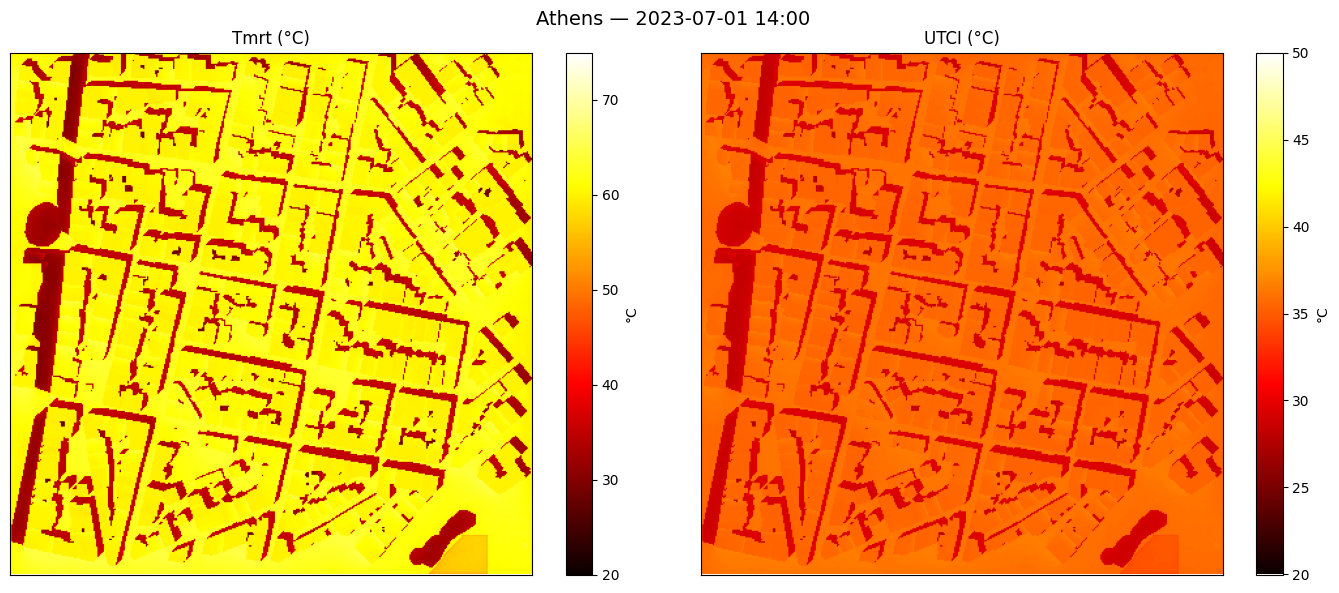

UTCI range: 27.7 – 36.7°C


In [3]:
OUTPUT_DIR = WORK_DIR / "output_comfort"

summary = solweig.calculate(
    surface=surface,
    weather=[weather_14h],
    location=location,
    output_dir=str(OUTPUT_DIR),
    outputs=["tmrt", "utci", "shadow"],
)

# Load per-timestep outputs from disk
tmrt, *_ = solweig.io.load_raster(str(OUTPUT_DIR / "tmrt" / "tmrt_20230701_1400.tif"))
shadow, *_ = solweig.io.load_raster(str(OUTPUT_DIR / "shadow" / "shadow_20230701_1400.tif"))
utci, *_ = solweig.io.load_raster(str(OUTPUT_DIR / "utci" / "utci_20230701_1400.tif"))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(tmrt, cmap="hot", vmin=20, vmax=75)
axes[0].set_title("Tmrt (°C)")
plt.colorbar(im0, ax=axes[0], label="°C")

im1 = axes[1].imshow(utci, cmap="hot", vmin=20, vmax=50)
axes[1].set_title("UTCI (°C)")
plt.colorbar(im1, ax=axes[1], label="°C")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(f"Athens — {weather_14h.datetime:%Y-%m-%d %H:%M}", fontsize=14)
plt.tight_layout()
plt.show()

print(f"UTCI range: {np.nanmin(utci):.1f} – {np.nanmax(utci):.1f}°C")

## 3. UTCI stress-category map

Classify each pixel into UTCI thermal stress categories using a discrete colour scale.


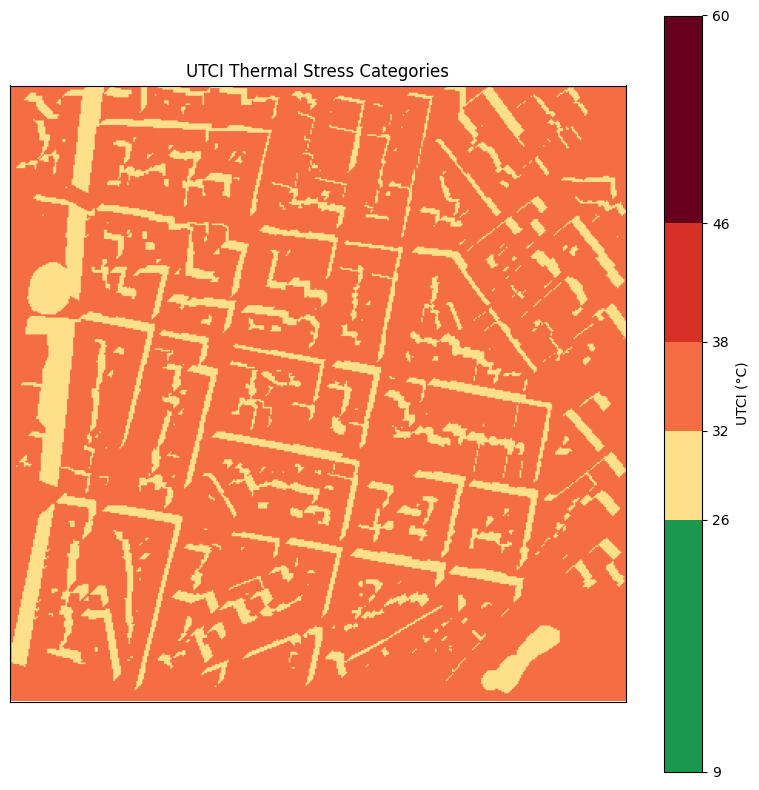

Area by UTCI stress category:
  No stress       (9–26°C):   0.0%
  Moderate        (26–32°C):  18.5%
  Strong          (32–38°C):  81.5%
  Very strong     (38–46°C):   0.0%
  Extreme         (46–60°C):   0.0%


In [4]:
# UTCI stress categories and colours
utci_bounds = [9, 26, 32, 38, 46, 60]
utci_labels = ["No stress", "Moderate", "Strong", "Very strong", "Extreme"]
utci_colors = ["#1a9850", "#fee08b", "#f46d43", "#d73027", "#67001f"]

cmap = ListedColormap(utci_colors)
norm = BoundaryNorm(utci_bounds, cmap.N)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(utci, cmap=cmap, norm=norm)
cbar = plt.colorbar(im, ax=ax, ticks=utci_bounds, spacing="proportional")
cbar.set_label("UTCI (°C)")
ax.set_title("UTCI Thermal Stress Categories")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

# Print area fractions per category
valid = ~np.isnan(utci)
total = valid.sum()
print("Area by UTCI stress category:")
for i, label in enumerate(utci_labels):
    lo, hi = utci_bounds[i], utci_bounds[i + 1]
    frac = ((utci >= lo) & (utci < hi) & valid).sum() / total * 100
    print(f"  {label:15s} ({lo}–{hi}°C): {frac:5.1f}%")

## 4. Shade benefit: sun vs. shade statistics

Quantify how much thermal stress is reduced in shaded areas versus sunlit areas.


In [5]:
sunlit = shadow > 0.5
shaded = shadow < 0.5

tmrt_sun = np.nanmean(tmrt[sunlit])
tmrt_shd = np.nanmean(tmrt[shaded])
utci_sun = np.nanmean(utci[sunlit])
utci_shd = np.nanmean(utci[shaded])

print("        Sunlit    Shaded    Difference")
print(f"Tmrt:   {tmrt_sun:6.1f}°C  {tmrt_shd:6.1f}°C  {tmrt_sun - tmrt_shd:+6.1f}°C")
print(f"UTCI:   {utci_sun:6.1f}°C  {utci_shd:6.1f}°C  {utci_sun - utci_shd:+6.1f}°C")

        Sunlit    Shaded    Difference
Tmrt:     61.3°C    34.0°C   +27.2°C
UTCI:     35.8°C    29.2°C    +6.6°C
